## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 1 - Notebook 1A - From images to features
## Flavia Leaf Dataset
---

## Importing the Required Libraries
---

In [4]:
import os

import numpy as np
from skimage import util, io, transform, filters, color, measure

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The dataset
---

**Flavia leaf dataset** (Wu et al., 2007)
* A set of leaf images
* 1,907 images
* 33 classes

* **Versions of the Flavia set:**
    * Full dataset (all images of 33 classes)
        * ```data/flavia```
    * All images of 3 selected classes
        * ```data/flavia_toy```
    * Only 6 images of 3 selected classes
        * ```data/flavia_toy2```

In [5]:
# *** Uncomment the dataset you want to use ***
# ---------------------------------------------
# (1) Full dataset - 33 classes 
### ds_path = 'data/flavia'

# (2) Full dataset - 3 classes 
ds_path = 'data/flavia_toy'

# (3) 6 images per class - 3 classes 
### ds_path = 'data/flavia_toy2'

print(f'Path to selected dataset: {ds_path}')

Path to selected dataset: data/flavia_toy


## Loading the images from the dataset
---

The dataset is organized into folders, with one folder for each class:

    dataset/
    ├── class_1/
    │   ├── image_1.jpg
    │   ├── image_2.jpg
    │   └── ...
    ├── class_2/
    │   ├── image_1.jpg
    │   ├── image_2.jpg
    │   └── ...
    └── ...

The images are loaded from the class folders and resized to reduce their spatial dimensions. 

The corresponding class labels and filenames are also stored for later use.

In [6]:
# List of class names (folder names)
class_names = sorted(os.listdir(ds_path))

# Lists to store the dataset
images = []
labels = []
filenames = []

# Iterate over the classes
for class_name in class_names:

    # Path to the current class folder
    class_path = os.path.join(ds_path, class_name)
    # List of image filenames in the current class
    class_filenames = sorted(os.listdir(class_path))

    # Iterate over the images in the current class
    for filename in class_filenames:

        image_path = os.path.join(class_path, filename)

        # Load the image
        image = io.imread(image_path)

        # Resize the image to 1/4 of its original dimensions
        new_size = (image.shape[0] // 4, image.shape[1] // 4)
        image = transform.resize(image, new_size, anti_aliasing=True)

        # Store the image and its metadata
        images.append(image)
        labels.append(class_name)
        filenames.append(filename)

# Convert the labels to a NumPy array
labels = np.array(labels)

# Display dataset information
print(f"Number of images: {len(images)}")
print(f"Number of labels: {len(labels)}")
print(f"Classes: {class_names}")
print()

# Display some labels for verification.
print("First 5 labels:", labels[:5])
print("Middle 5 labels:", labels[len(labels)//2 - 2:len(labels)//2 + 3])
print("Last 5 labels:", labels[-5:])


Number of images: 191
Number of labels: 191
Classes: ['acer_palmatum', 'aesculus_chinensis', 'cersis_chinensis']

First 5 labels: ['acer_palmatum' 'acer_palmatum' 'acer_palmatum' 'acer_palmatum'
 'acer_palmatum']
Middle 5 labels: ['aesculus_chinensis' 'aesculus_chinensis' 'aesculus_chinensis'
 'aesculus_chinensis' 'aesculus_chinensis']
Last 5 labels: ['cersis_chinensis' 'cersis_chinensis' 'cersis_chinensis'
 'cersis_chinensis' 'cersis_chinensis']


### Visualizing Dataset Images

Display the first `N` images from each class to visually inspect the dataset and its class variability.

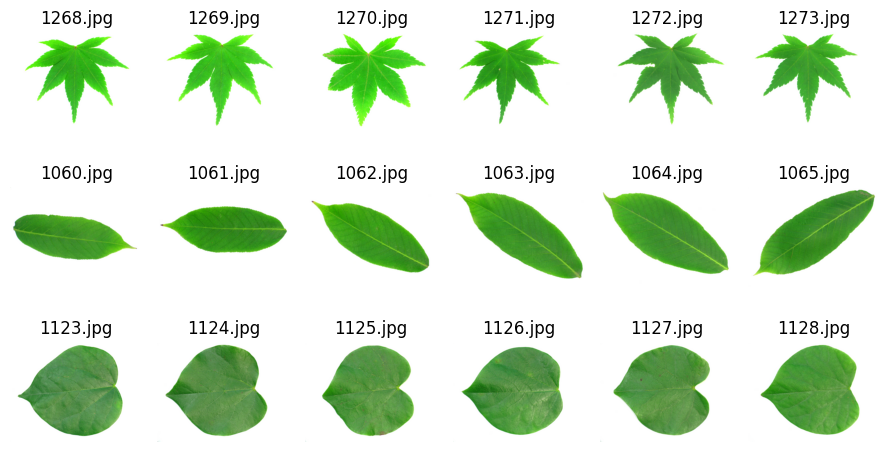

In [7]:
# Number of images to show per class
n_images = 6

# Select the first N images from each class
image_list_temp = []
filename_list_temp = []

for class_name in class_names:
    # Indices of images belonging to the current class
    indices = np.where(labels == class_name)[0][:n_images]

    for idx in indices:
        image_list_temp.append(images[idx])
        filename_list_temp.append(filenames[idx])

# Display the selected images
fig, ax = plt.subplots(len(class_names), n_images, figsize=(9, 5))

for i, (image, filename) in enumerate(zip(image_list_temp, filename_list_temp)):
    row = i // n_images
    col = i % n_images

    ax[row, col].imshow(image)
    ax[row, col].set_title(filename)
    ax[row, col].axis('off')

fig.tight_layout()
plt.show()

## Extracting Features from Images
---

In this step, we will extract **shape features** from each leaf:

- Area
- Major axis length
- Minor axis length
- Solidity
- Eccentricity

Before extracting these features, we first need to **segment the leaf** from the background. The main steps are:

1. Convert the image to floating-point format;
2. Convert the image from RGB to grayscale;
3. Segment the image using **Otsu's thresholding method**;
4. Identify the connected objects in the binary image;
5. Keep the **largest object**, which is assumed to be the leaf;
6. Extract the shape features from the segmented leaf.

The extracted features will be stored in a **feature matrix**, where each row represents an image and each column represents a feature.

In [8]:
# Feature names
features = ['area', 'major_axis', 'minor_axis', 'solidity', 'eccentricity']

# Feature matrix: one row per image, one column per feature
feature_mat = []

# Segmented (binary) images
seg_list = []

# Iterate over the images and their corresponding labels
for i, (image, label) in enumerate(zip(images, labels)):
    ### print(f'Image {i} - Class {label}')

    # Image segmentation
    # --------------------------------------------------
    # Convert the image to grayscale
    img_gray = color.rgb2gray(util.img_as_float(image))

    # Segment the image using Otsu thresholding
    threshold = filters.threshold_otsu(img_gray)
    img_seg = img_gray < threshold

    # Label connected objects
    img_lbl = measure.label(img_seg)

    # Compute properties of all detected objects
    props = measure.regionprops(img_lbl)

    # Select the largest object (the leaf)
    prop = max(props, key=lambda prop: prop.area)

    # Keep only the largest object
    img_seg = img_lbl == prop.label

    # Assemble the feature vector
    feature_list = [
        prop.area,
        prop.axis_major_length,
        prop.axis_minor_length,
        prop.solidity,
        prop.eccentricity
    ]

    # Store results
    feature_mat.append(feature_list)
    seg_list.append(img_seg)

# Convert the feature matrix to a NumPy array
feature_mat = np.array(feature_mat)

# Print the shape of the feature matrix
print(f"Shape of feature matrix: {feature_mat.shape}")

Shape of feature matrix: (191, 5)


### Visualizing the Segmented Images

Display the first `N` segmented images from each class to visually inspect the segmentation results.

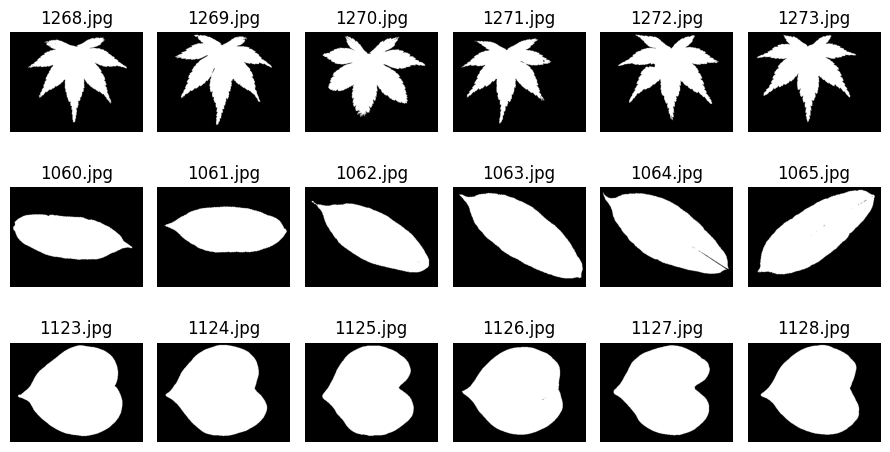

In [9]:
# Number of images to show per class
n_images = 6

# Select the first N images from each class
image_list_temp = []
filename_list_temp = []

for class_name in class_names:
    # Indices of images belonging to the current class
    indices = np.where(labels == class_name)[0][:n_images]

    for idx in indices:
        image_list_temp.append(seg_list[idx])
        filename_list_temp.append(filenames[idx])

# Display the selected images
fig, ax = plt.subplots(len(class_names), n_images, figsize=(9, 5))

for i, (image, filename) in enumerate(zip(image_list_temp, filename_list_temp)):
    row = i // n_images
    col = i % n_images

    ax[row, col].imshow(image, cmap='gray')
    ax[row, col].set_title(filename)
    ax[row, col].axis('off')

fig.tight_layout()
plt.show()

## Visualizing the Extracted Features
---

The distributions of the extracted features and their pairwise relationships are visualized for each class. 
This helps identify features that may be useful for distinguishing between classes.

In [10]:
df = pd.DataFrame(feature_mat, columns=features)
df['class'] = labels

display(df)

,area,major_axis,minor_axis,solidity,eccentricity,class
0,29343.0,232.281208,199.518361,0.552859,0.512056,acer_palmatum
1,31000.0,233.578582,212.609306,0.544270,0.414112,acer_palmatum
2,35427.0,258.018451,208.843834,0.644573,0.587238,acer_palmatum
3,27024.0,223.574946,195.071631,0.521790,0.488594,acer_palmatum
4,30955.0,244.178098,204.482744,0.517175,0.546540,acer_palmatum
...,...,...,...,...,...,...
186,52765.0,275.852077,249.970513,0.959748,0.422901,cersis_chinensis
187,55372.0,278.676062,256.002113,0.969177,0.395103,cersis_chinensis
188,50416.0,278.639734,236.245475,0.955754,0.530232,cersis_chinensis
189,51698.0,271.726867,246.742366,0.964983,0.418856,cersis_chinensis


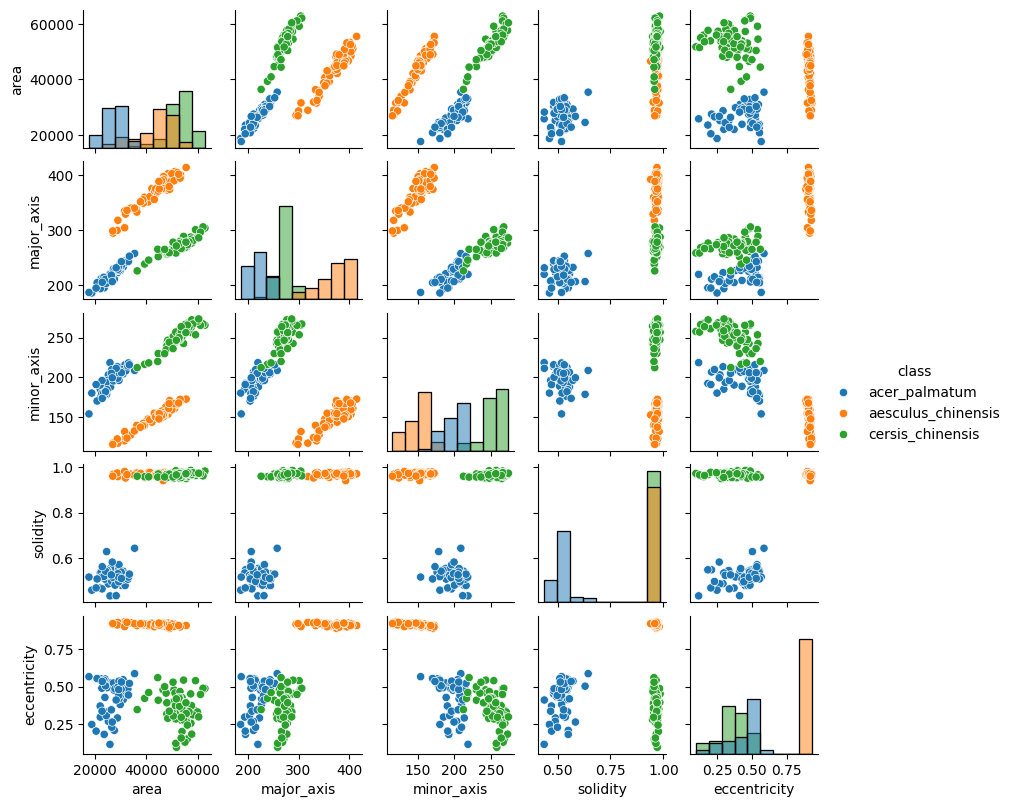

In [11]:
g = sns.PairGrid(df, hue='class', vars=features)
g.fig.set_size_inches(8, 8)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

## Creating and Saving the Feature Dataset
---

The extracted features are organized into a tabular dataset, with one row per image and the corresponding filename and class label. 

The dataset is then saved to a CSV file for use in the classification notebooks.

In [12]:
# Create a DataFrame with the extracted features
features_df = pd.DataFrame(feature_mat, columns=features)

# Add image filenames and class labels
features_df.insert(0, "filename", filenames)
features_df.insert(1, "label", labels)

# Display the dataset
features_df.head()

,filename,label,area,major_axis,minor_axis,solidity,eccentricity
0,1268.jpg,acer_palmatum,29343.0,232.281208,199.518361,0.552859,0.512056
1,1269.jpg,acer_palmatum,31000.0,233.578582,212.609306,0.544270,0.414112
2,1270.jpg,acer_palmatum,35427.0,258.018451,208.843834,0.644573,0.587238
3,1271.jpg,acer_palmatum,27024.0,223.574946,195.071631,0.521790,0.488594
4,1272.jpg,acer_palmatum,30955.0,244.178098,204.482744,0.517175,0.546540


In [13]:
# Save the feature dataset
features_df.to_csv("flavia_features.csv", index=False)

## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---

* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* Scikit-image documentation.
    - https://scikit-image.org/docs/stable/
    
**Flavia Leaf Dataset:**
* WU, S.G.;  BAO, F.S; XU, E.Y.; WANG, Y.-X.; CHANG, Y.-F.; XIANG, Q.-L. A Leaf Recognition Algorithm for Plant classification Using Probabilistic Neural Network. IEEE 7th International Symposium on Signal Processing and Information Technology, Dec. 2007, Cairo, Egypt.
    - https://doi.org/10.1109/ISSPIT.2007.4458016 
    - Flavia Leaf Dataset: https://flavia.sourceforge.net/  